In [95]:
import numpy as np
import seaborn as sns
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse
import xgboost as xgb

In [96]:
by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'
by_day_data_list = [x for x in os.listdir(by_day_data) if 'train.csv' in x]
dtypes = pd.read_csv(f'{os.path.join(by_day_data,by_day_data_list[0])}', nrows=1).iloc[0].to_dict()

def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path,
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [97]:
daily_df = read_csv(by_day_data+by_day_data_list[0])
daily_df = daily_df[daily_df['date'].between(pd.Timestamp('2024-07-30'), pd.Timestamp('2025-09-01'), inclusive='left')]

daily_df = daily_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

In [98]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),Avg. spd (km/h),RT dist (km),Interruption
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0


In [99]:
# I want to add daily weather data.
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [100]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.head()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
197,2025-08-31,16.39,57.5,9.1,8.5,0.0,100.36,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:40:00,0 days 19:55:00,13.25,2.0
198,2025-08-30,15.00,58.5,7.5,13.0,31.0,99.96,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:39:00,0 days 19:57:00,13.30,3.5
199,2025-08-29,13.55,64.5,6.0,19.5,31.0,99.73,24100,1.7,0.0,0.0,0.0,0.0,0 days 06:38:00,0 days 19:59:00,13.35,4.0
200,2025-08-28,14.95,73.5,11.8,17.5,32.0,99.53,18500,2.2,5.4,5.4,0.0,0.0,0 days 06:36:00,0 days 20:00:00,13.40,4.0
201,2025-08-27,17.00,58.0,6.7,19.5,26.0,99.86,24100,2.1,0.0,0.0,0.0,0.0,0 days 06:35:00,0 days 20:02:00,13.45,3.0


In [101]:
daily_df = pd.merge(daily_df, weather, on='date')

In [102]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0


In [103]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)
daily_df = daily_df[~((daily_df['dt_short'] == 0)&(daily_df['gap'] == 0)&(daily_df['bunch'] == 0))]

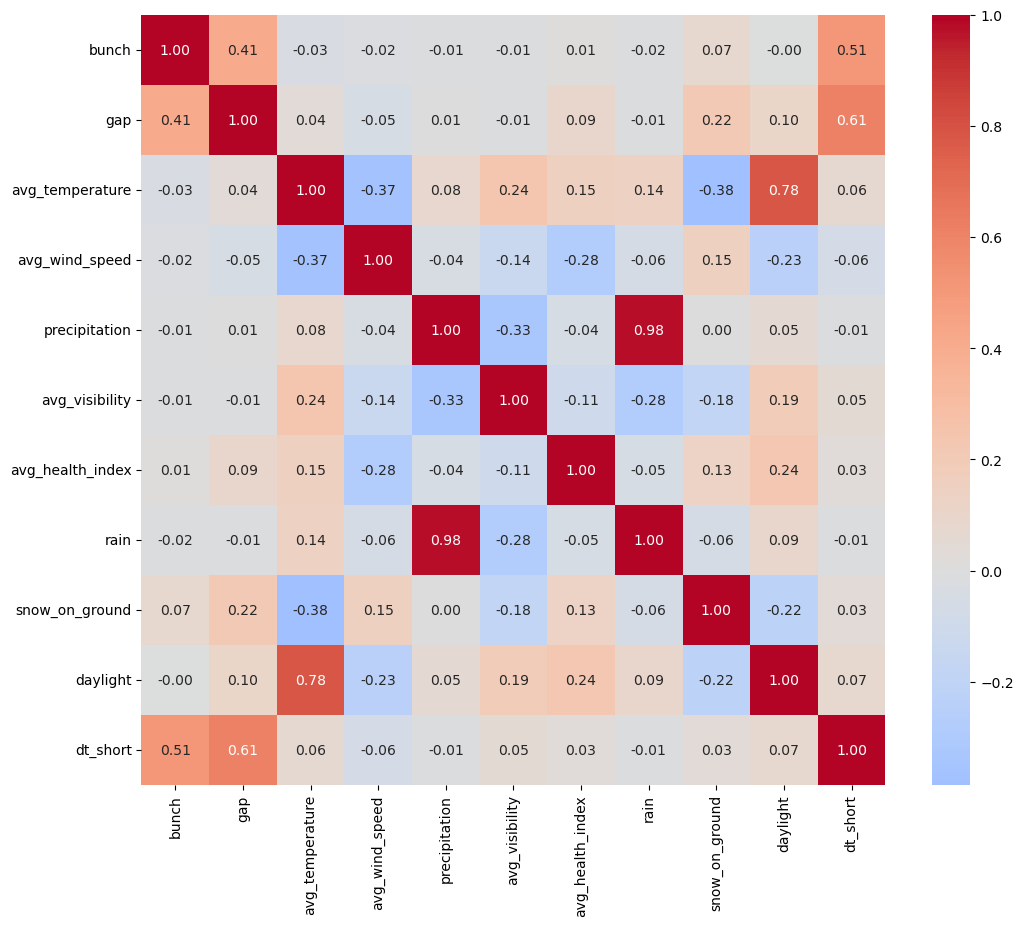

In [104]:
features = ['bunch', 'gap','avg_temperature', 'avg_wind_speed', 'precipitation', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight']
targets = [x for x in daily_df.columns if 'dt_short' in x]

corr_matrix = daily_df[features+targets].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f');

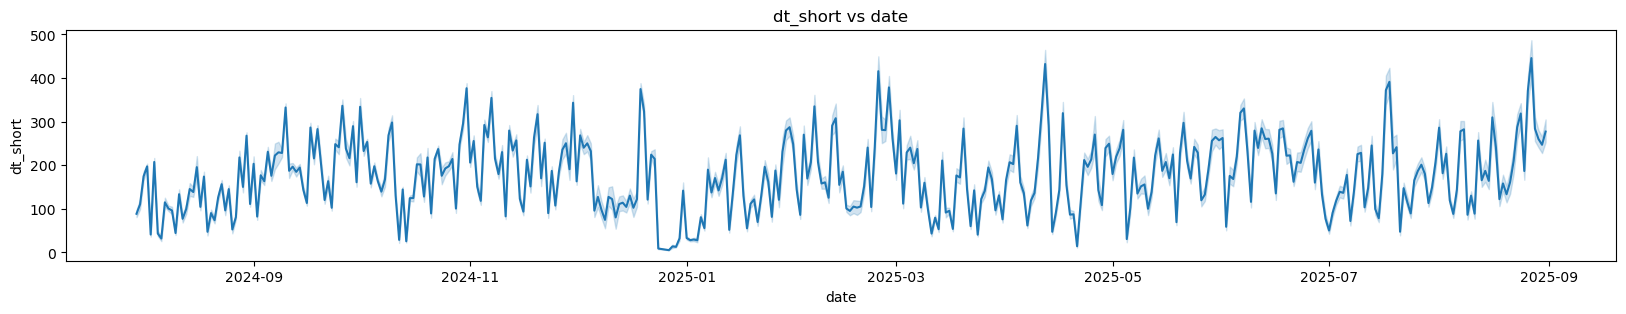

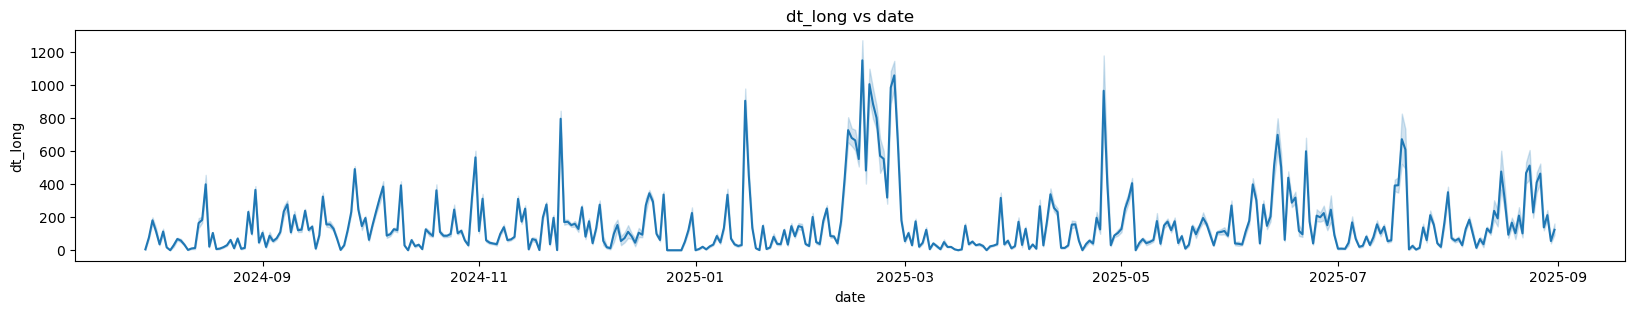

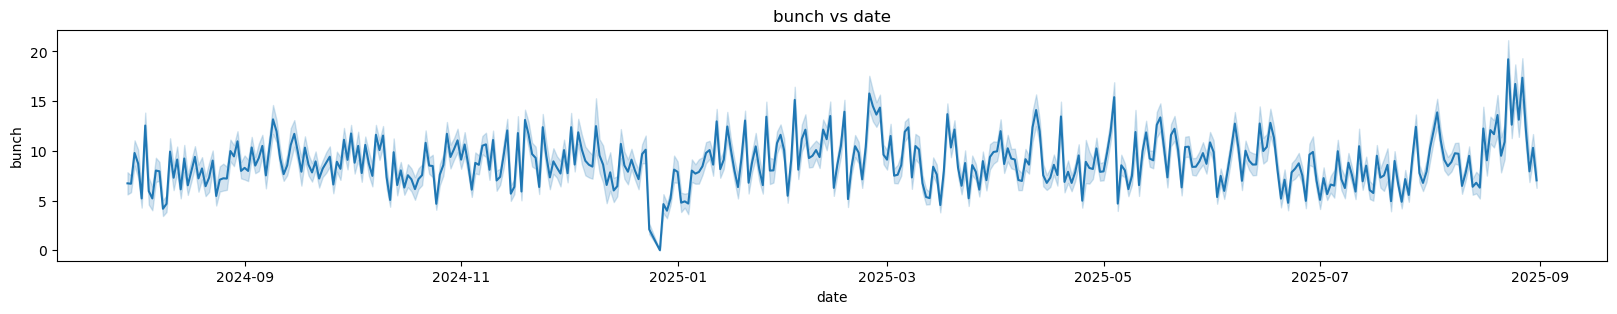

In [105]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20, 3))
    sns.lineplot(data=daily_df[daily_df['dt_short'] != 0], x='date', y=dt)
    plt.title(f'{dt} vs date')
    plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=daily_df[daily_df['dt_short'] != 0], x='date', y='bunch')
plt.title('bunch vs date')
plt.show()

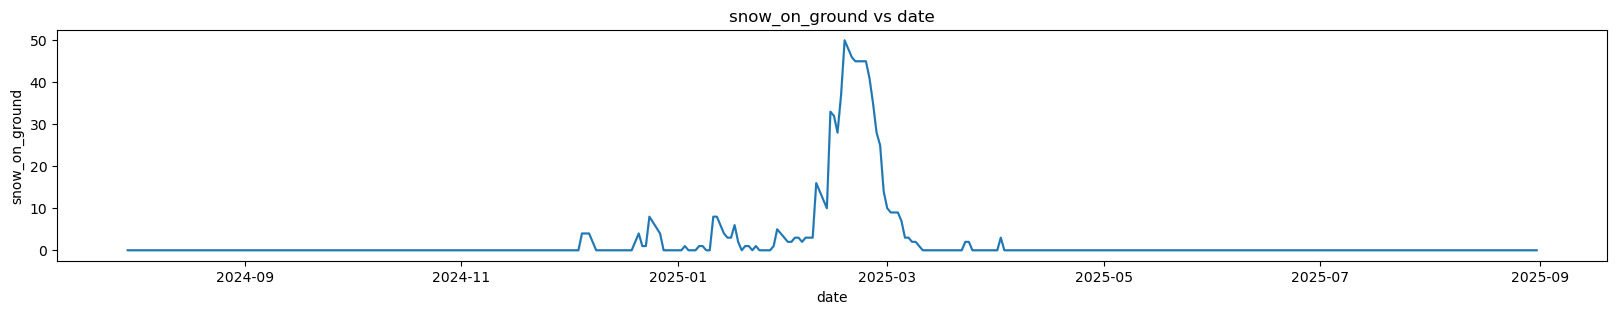

In [106]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.title('snow_on_ground vs date')
plt.show()

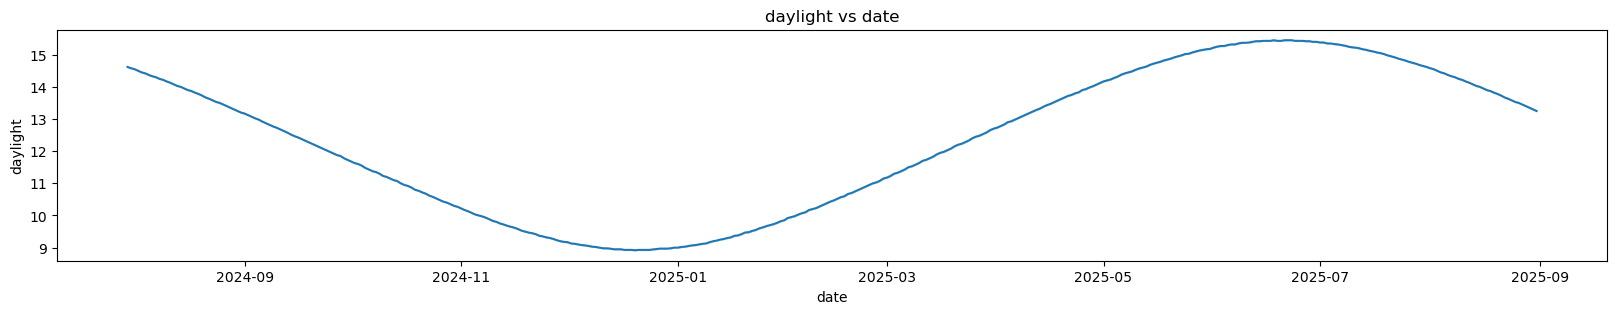

In [107]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.title('daylight vs date')
plt.show()

<Axes: xlabel='dt_short', ylabel='Count'>

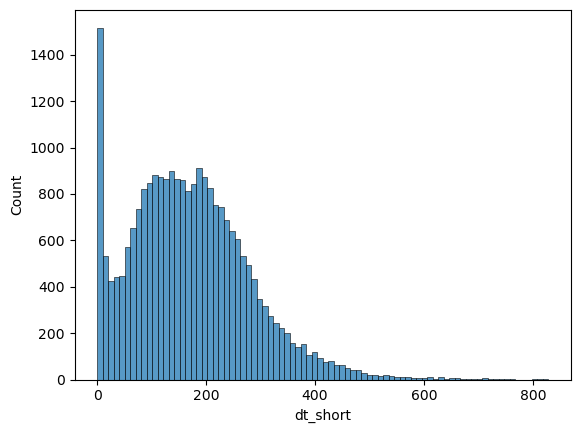

In [108]:
sns.histplot(daily_df['dt_short'])

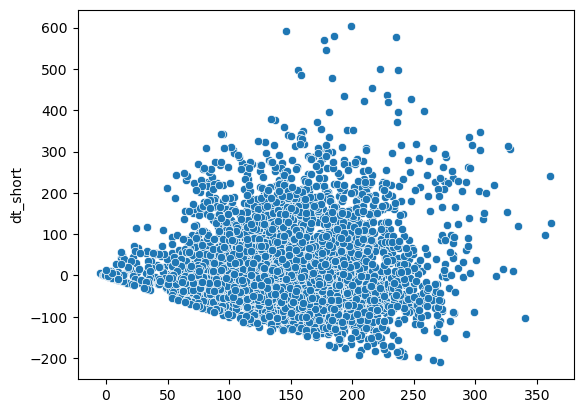

count    4069.000000
mean      169.776194
std       118.389157
min         0.000000
25%        83.800000
50%       148.383333
75%       235.083333
max       812.733333
Name: dt_short, dtype: float64
dt_short rmse mean: 95.18575681950938
dt_short rmse std: 7.62656138617655
dt_short average R^2 score: 0.27132717602955103
dt_short R^2 score std: 0.07647410941208173



In [109]:
# Let's try xgboost since it is a very flexible model

# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain',
            'snow_on_ground',
            'daylight', 'dir', 'stop']



tss = TimeSeriesSplit(n_splits=5)
target = 'dt_short'
for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
    df_train = daily_df.iloc[tss_train]
    df_test = daily_df.iloc[tss_test]

    model = xgb.XGBRegressor(objective='reg:squarederror',
                            n_estimators=100,
                            enable_categorical=True,
                            learning_rate=0.1,
                            subsample=0.8,
                            max_depth=10,
                            reg_alpha=4,
                            reg_lambda=0)

    X_train = df_train[features]
    y_train = df_train[target]
    X_test = df_test[features]
    y_test = df_test[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    R2_score[target,idx] = r2_score(y_test, y_pred)
    loss[target,idx] = rmse(y_test, y_pred)
    if idx ==2:
        y_resid = y_test-y_pred
        sns.scatterplot(x=y_pred, y=y_resid)
        plt.show()
        
        print(y_test.describe())


dt = 'dt_short'
print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

That gap seems to be so dominant is very suspicious, especially since gapping events are defined as gaps between streetcars that are at least 19 minutes long. Therefore, we rerun the model without it.

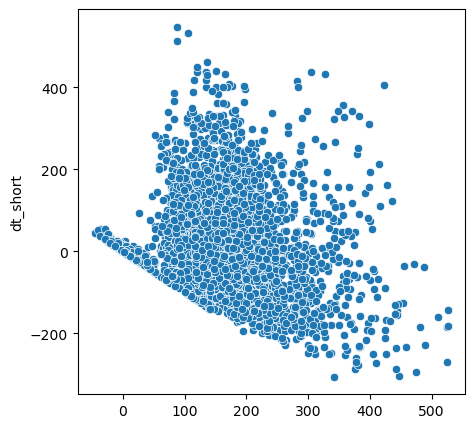

dt_short rmse mean: 113.93285618362282
dt_short rmse std: 7.527282071850959
dt_short average R^2 score: -0.057737378911880445
dt_short R^2 score std: 0.2003631839227854



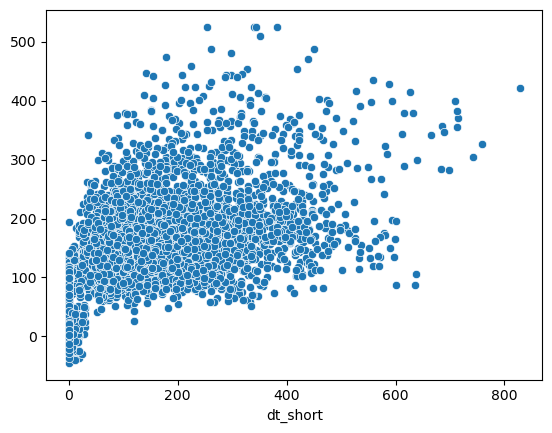

In [110]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')


tss = TimeSeriesSplit(n_splits=5)
target = 'dt_short'
for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
    df_train = daily_df.iloc[tss_train]
    df_test = daily_df.iloc[tss_test]

    model = xgb.XGBRegressor(objective='reg:squarederror',
                            n_estimators=100,
                            enable_categorical=True,
                            learning_rate=0.1,
                            max_depth=10,
                            subsample=0.5,
                            reg_lambda=4,
                            reg_alpha=1,
                            seed=37)

    X_train = df_train[features]
    y_train = df_train[target]
    X_test = df_test[features]
    y_test = df_test[target]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    R2_score[target,idx] = r2_score(y_test, y_pred)
    loss[target,idx] = rmse(y_test, y_pred)

    short_df = df_test[[x for x in features]].copy()
    short_df[target] = y_pred

    if idx ==4:
        plt.figure(figsize=(5, 5))
        y_resid = y_test-y_pred
        sns.scatterplot(x=y_pred, y=y_resid)
        plt.show()

        sns.scatterplot(x=y_test, y=y_pred)


dt='dt_short'
print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')



In [111]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5)
target = 'dt_short'
lambda_vals = [0,1,2,3,5,7,10]
alpha_vals = [0,1,2,3,4,5,7,10]
depth_vals = [5,10]
est_vals = [100]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                subsample=0.8,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [112]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

107.84053758503997 (2, 4, 5, 100) 0.03521049922658417 (5, 10, 5, 100)
[116.07098783751157, 108.74631109701468, 111.0390796263773, 104.05243237116899, 107.84053758503997]
[-0.18238673933408567, 0.01140818564260171, 0.12009741085542369, -0.04538053618557614, 0.2218858434296398]
[114.37356959013441, 105.80899112050889, 108.03022272678324, 106.93357954658798, 109.55457958546063]
[-0.14805723670536475, 0.06409215071874208, 0.1671372629336575, -0.10407390571418818, 0.1969542249000742]


In [113]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

107.84053758503997 (2, 4, 5, 100) 0.03521049922658417 (5, 10, 5, 100)
[116.07098783751157, 108.74631109701468, 111.0390796263773, 104.05243237116899, 107.84053758503997]
[-0.18238673933408567, 0.01140818564260171, 0.12009741085542369, -0.04538053618557614, 0.2218858434296398]
[114.37356959013441, 105.80899112050889, 108.03022272678324, 106.93357954658798, 109.55457958546063]
[-0.14805723670536475, 0.06409215071874208, 0.1671372629336575, -0.10407390571418818, 0.1969542249000742]


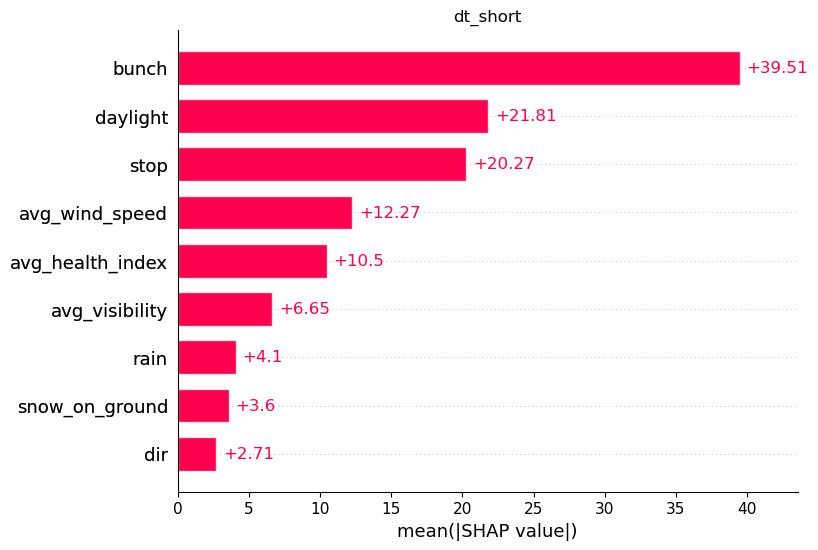

In [114]:
import shap
shap.initjs()

df_filter = dict()
y_filter = dict()
X_filter= dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
target = 'dt_short'
df_filter[target] = daily_df
X_filter[target] = df_filter[target][[x for x in features]]
y_filter[target] = df_filter[target][target]

model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    enable_categorical=True,
    subsample=0.8,
    max_depth=15,
    reg_lambda=6,
    reg_alpha=10,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])


explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

Finally, we compare the performace with test data.

In [115]:
by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'
test_data_list = [x for x in os.listdir(by_day_data) if 'test.csv' in x]
test_df = read_csv(by_day_data+test_data_list[0])

test_df = test_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

# I want to add daily weather data.
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [116]:
first_date = test_df['date'].min()
last_date = test_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]

In [117]:
test_df = pd.merge(test_df, weather, on='date')

In [118]:
# Fill na values with 0 and prune outliers
test_df.fillna(0, inplace=True)
test_df = test_df[~((test_df['dt_short'] ==0)&(test_df['gap'] ==0)&(test_df['bunch'] ==0))]

122.91045726020701
-0.13098032596543696


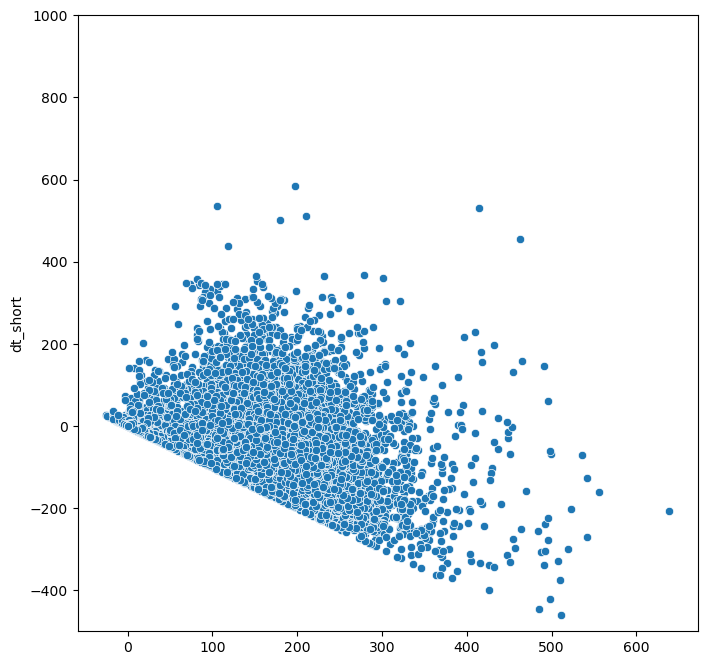

In [119]:
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
test_df['stop']=test_df['stop'].astype('category')
test_df['dir']=test_df['dir'].astype('category')

daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

X_test = test_df[[x for x in features]]
y_test = test_df['dt_short']

X_train = daily_df[[x for x in features]]
y_train = daily_df['dt_short']

model = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=100,
                        enable_categorical=True,
                        learning_rate=0.1,
                        subsample=0.7,
                        max_depth=10,
                        reg_lambda=0,
                        reg_alpha=5,
                        seed=37)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(rmse(y_test,y_pred))
print(r2_score(y_test,y_pred))

plt.figure(figsize=(8, 8))
y_resid = y_test-y_pred
sns.scatterplot(x=y_pred, y=y_resid)
plt.ylim(-500,1000)
plt.show()


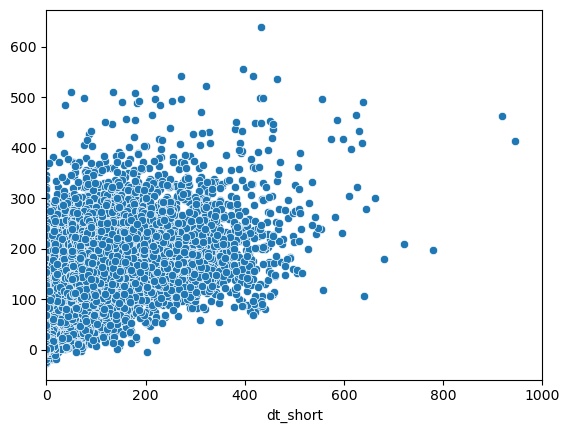

In [120]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlim(0,1000)
plt.show()

In [121]:
loss = dict()
R2_score = dict()
features = ['bunch', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5)
target = 'dt_short'
lambda_vals = [0,1,2,3,4,5,6,7,10, 13, 15]
alpha_vals = [0,1,2,3,4,5,6,7,10, 13, 15]
depth_vals = [5,10,15]
est_vals = [100]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                subsample=0.8,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [122]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

107.23793900748699 (0, 0, 5, 100) 0 (0, 0, 0, 0)
[149.779213053036, 109.32199958308453, 112.95800315413369, 103.44225474735248, 107.23793900748699]
[-0.9688620053605224, 0.0009135335596524019, 0.08942252756951385, -0.033155977369724754, 0.23055754417541086]


KeyError: ((0, 0, 0, 0), 0)

count    26280.000000
mean        64.277321
std         89.451401
min        -10.224603
25%          0.105317
50%          1.782406
75%        142.453934
max        594.177429
dtype: float64
count    26280.000000
mean        49.876944
std         95.139016
min          0.000000
25%          0.000000
50%          0.000000
75%         77.841667
max       6355.766667
Name: dt_short, dtype: float64
71.87730776425046
0.4292015034960046


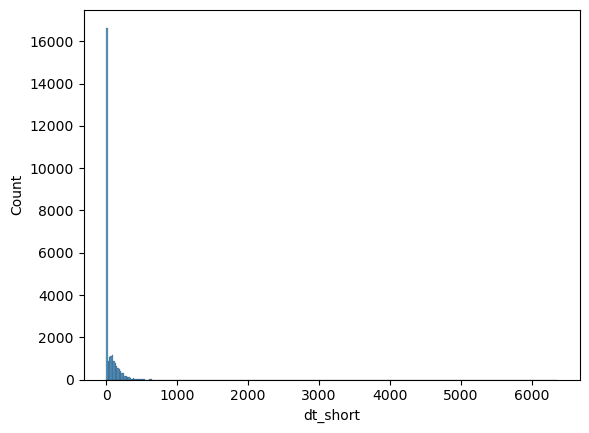

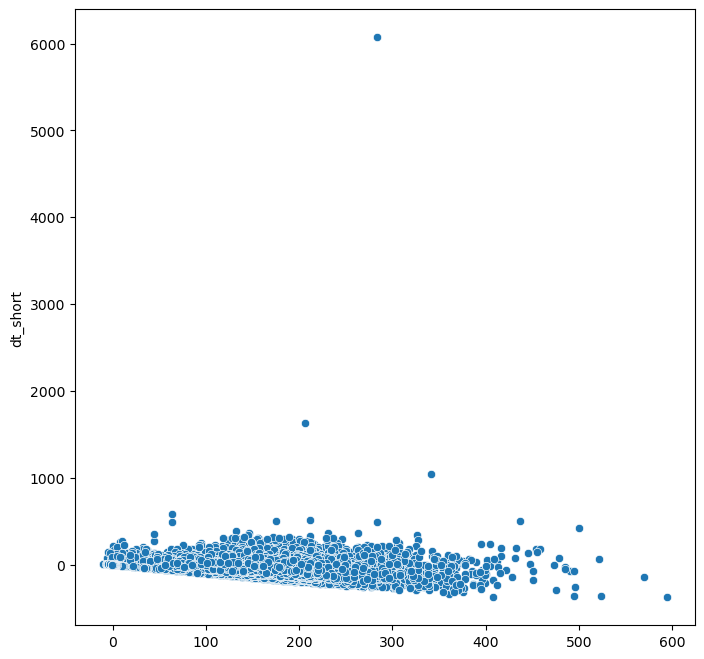

In [ ]:
test_df['stop']=test_df['stop'].astype('category')
test_df['dir']=test_df['dir'].astype('category')

features = ['bunch', 'daylight', 'dir', 'stop']

X_train = daily_df[[x for x in features]]
y_train = daily_df['dt_short']

X_test = test_df[[x for x in features]]
y_test = test_df['dt_short']

model =xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                subsample=0.8,
                                max_depth=5,
                                reg_lambda=4,
                                reg_alpha=5,
                                seed=37)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print(pd.Series(y_pred).describe())
print(pd.Series(y_test).describe())

print(rmse(y_test,y_pred))
print(r2_score(y_test,y_pred))

short_df = test_df[[x for x in features]].copy()
short_df['dt_short'] = y_pred
sns.histplot(x=y_test)
plt.show()

plt.figure(figsize=(8, 8))
y_resid = y_test-y_pred
sns.scatterplot(x=y_pred, y=y_resid)
plt.show()



Finally, we check the quality of a baseline model.

In [ ]:
baseline = dict()
for dt in ['dt_short', 'dt_long']:
    for stop in daily_df.stop.unique():
        for dir in ['E', 'W']:
            baseline[dt, stop, dir] = daily_df[(daily_df['stop'] == stop) & (daily_df['dir'] == dir)][dt].mean()

baseline_df = test_df[['dir', 'stop']].copy()

dt_list = dict()
for dt in ['dt_short', 'dt_long']:
    dt_list[dt] = []

for row in range(baseline_df.shape[0]):
    curr_stop = baseline_df['stop'].iloc[row]
    curr_dir = baseline_df['dir'].iloc[row]
    for dt in ['dt_short', 'dt_long']:
        dt_list[dt].append(baseline[dt, curr_stop, curr_dir])

for dt in ['dt_short', 'dt_long']:
    baseline_df[dt] = dt_list[dt]



In [ ]:
print(f'Performance of baseline model on dt_short RMSE: {rmse(test_df['dt_short'], baseline_df['dt_short'])}')

Performance of baseline model on dt_short RMSE: 90.77505542786638
Performance of baseline model on dt_long RMSE: 124.29887427828558
